In [109]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


In [110]:
def load_path(path, part):
    dataset = []

    for folder in os.listdir(path):
        folder = path + '/' + str(folder)
        if os.path.isdir(folder):
            for body in os.listdir(folder):
                if body == part:
                    path_p = folder + '/' + body
                    for pid in os.listdir(path_p):
                        path_id = path_p + '/' + pid
                        for lab in os.listdir(path_id):

                            if lab.split('_')[-1] == 'positive':
                                label = 'fractured'
                            else:
                                label = 'normal'

                            path_l = path_id + '/' + lab
                            for img in os.listdir(path_l):
                                dataset.append({
                                    'Filepath': path_l + '/' + img,
                                    'Label': label
                                })

    return dataset


In [111]:
import os

THIS_FOLDER = os.getcwd()     # notebook-safe
image_dir = os.path.join(THIS_FOLDER, "Dataset")


data = load_path(image_dir, "Hand")

filepaths = []
labels = []

for row in data:
    filepaths.append(row['Filepath'])
    labels.append(row['Label'])

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)


In [126]:
train_df, test_df = train_test_split(
    images,
    train_size=0.9,
    shuffle=True,
    random_state=1
)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    seed=42,
    subset='training'
)
val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    seed=42,
    subset='validation'
)
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 4803 validated image filenames belonging to 2 classes.
Found 1200 validated image filenames belonging to 2 classes.
Found 601 validated image filenames belonging to 2 classes.


In [ ]:
base_model = tf.keras.applications.EfficientNetB1(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

In [ ]:
inputs = base_model.input

x = tf.keras.layers.Dense(128, activation='relu')(base_model.output)
x = tf.keras.layers.Dense(50, activation='relu')(x)

outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[callbacks]
)

Epoch 1/10


c:\Users\Uday p\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


76/76 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.7144 - loss: 0.6028 - val_accuracy: 0.7308 - val_loss: 0.5653
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.7292 - loss: 0.5564 - val_accuracy: 0.7458 - val_loss: 0.5440
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.7505 - loss: 0.5329 - val_accuracy: 0.7608 - val_loss: 0.5249
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7559 - loss: 0.5184 - val_accuracy: 0.7642 - val_loss: 0.5195
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.7707 - loss: 0.5022 - val_accuracy: 0.7650 - val_loss: 0.5144
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.7661 - loss: 0.4969 - val_accuracy: 0.7642 - val_loss: 0.5151
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.7878 - loss: 0.4749 - val_accuracy: 0.7783 - val_loss: 0.4967
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7853 - loss: 0.4775 - val_accuracy: 0.7642 - val_loss: 0.

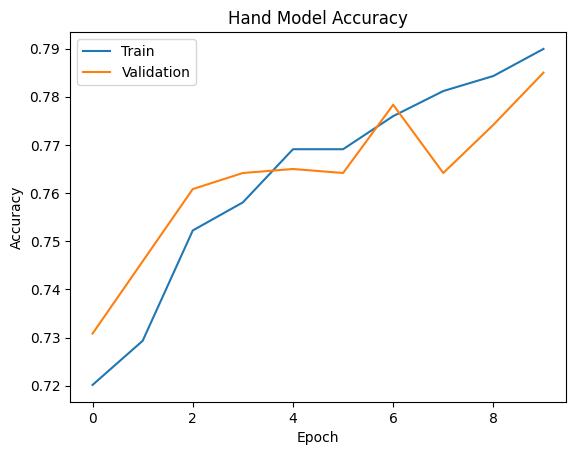

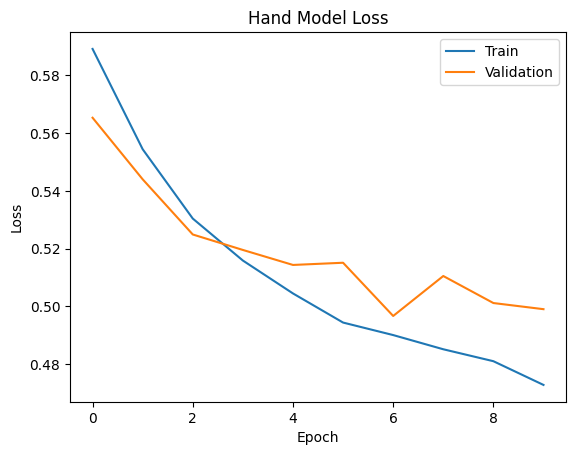

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Hand Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Hand Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [139]:
model.save(os.path.join(THIS_FOLDER, 'weights/EfficientNetB1_Hand.h5'))
